In [1]:
import numpy as np
import polars as pl
import ssm
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# based on https://github.com/lindermanlab/ssm/blob/master/doc/notebooks/2-Input-Driven-HMM.md

In [2]:
"""Load synthetic data of hdir cells and real mouse hdir"""
inpt = np.load(r"Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_flip_2023_09_03T12_04_16\processed_data\frame_by_synthetichdir_cluster_matrix.npy")
behave = pl.read_csv(r"Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_flip_2023_09_03T12_04_16\processed_data\full_video_dataframe.csv")
hdir = behave['hdir'].to_numpy()

In [69]:
"""Create states"""
case = "length" # "random", "half" 
# case 1: noise added to a random selection of state
if case == "random":
    state = np.random.normal(size = np.shape(inpt)[0])>0
# case 2: noise added to half the recording
if case == "half":
    state = np.zeros(len(hdir))
    state[int(len(hdir)/2):] = 1
if case == "matrix":
    states = [0,1]
    trans_matrix = [[.94,.06],[.02,.98]]
    start_prob = [.65,.35]
    all_state = np.zeros((len(hdir),),dtype = int)
    all_state[0] = np.random.choice(states,p=start_prob)
    for t in range(1,len(hdir)):
        trans = trans_matrix[all_state[t-1]]
        all_state[t] = np.random.choice(states,p=trans)
if case == "length":
    mean = [40*60*1,40*60*5] # (Hz*s*n_min)
    std = [40*10,40*10]
    # create initial segment
    start_prob = [.65,.35]
    s = np.random.choice(states,p=start_prob)
    if s == 1:
        all_state = np.append(s,np.ones(int(np.random.normal(loc = mean[1], scale = std[1]))))
    if s == 0:
        all_state = np.append(s,np.zeros(int(np.random.normal(loc = mean[0], scale = std[0]))))
    # create full sequence
    while len(all_state) < len(hdir):
        if all_state[-1] == 0:
            all_state = np.append(all_state,np.ones(int(np.random.normal(loc = mean[1], scale = std[1]))))
        if all_state[-1] == 1:
            all_state = np.append(all_state,np.zeros(int(np.random.normal(loc = mean[0], scale = std[0]))))
    # ensure appropriate length
    all_state = all_state[:len(hdir)]

In [70]:
"""Apply states"""
state_case = "rotation" # "diff_cells", "noise" 

if state_case == "noise":
    noise = np.random.normal(size = np.shape(inpt)[1])
    all_noisyinpt = np. zeros_like(inpt)
    all_noisyinpt[all_state == 0,:] = inpt[all_state == 0,:]
    all_noisyinpt[all_state == 1,:] = inpt[all_state == 1,:]*np.abs(noise) # +(np.ones_like(inpt[state == 1,:])*(noise))
if state_case == "diff_cells":
    all_noisyinpt = np. zeros_like(inpt)
    middle = int(np.shape(inpt)[1]/2)
    all_noisyinpt[all_state == 0,:middle] = inpt[all_state == 0,:middle]
    all_noisyinpt[all_state == 1,middle:] = inpt[all_state == 1,middle:]
if state_case == "scramble":
    all_noisyinpt = np. zeros_like(inpt)
    middle = int(np.shape(inpt)[1]/2)
    # in state 0 listen to the first half of cells
    all_noisyinpt[all_state == 0,:middle] = inpt[all_state == 0,:middle]
    x = inpt[all_state == 0,middle:]
    np.random.shuffle(x)
    all_noisyinpt[all_state == 0,middle:] = x
    # in state 1 listen to the first half of cells
    all_noisyinpt[all_state == 1,middle:] = inpt[all_state == 1,middle:]
    x = inpt[all_state == 1,:middle]
    np.random.shuffle(x)
    all_noisyinpt[all_state == 1,:middle] = x
if state_case == "rotation":
    all_noisyinpt = np. zeros_like(inpt)
    middle = int(np.shape(inpt)[1]/2)
    all_noisyinpt[all_state == 0,:] = inpt[all_state == 0,:]
    all_noisyinpt[all_state == 1,:] = np.roll(inpt[all_state == 1,:],middle, axis = 1)
if state_case == "sign_change":
    all_noisyinpt = np. zeros_like(inpt)
    all_noisyinpt[all_state == 0,:] = inpt[all_state == 0,:]
    all_noisyinpt[all_state == 1,:] = -inpt[all_state == 1,:]

# normalize input - seems to make no difference
# all_noisyinpt = all_noisyinpt/np.amax(all_noisyinpt, axis = 0)

# z-score input
# all_noisyinpt = all_noisyinpt - np.mean(all_noisyinpt, axis = 0)
# all_noisyinpt = all_noisyinpt - np.std(all_noisyinpt, axis = 0)

(array([82717., 27996., 23268., 28424., 37612., 55296., 85936., 64585.,
        60776., 89625.]),
 array([ 0. ,  1.1,  2.2,  3.3,  4.4,  5.5,  6.6,  7.7,  8.8,  9.9, 11. ]),
 <a list of 10 Patch objects>)

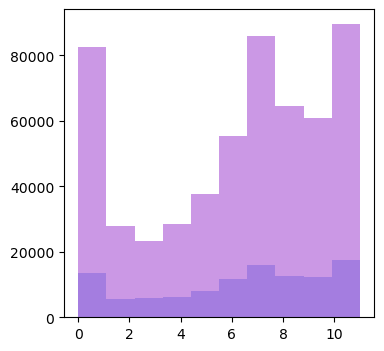

In [71]:
"""Bin hdir"""
number_of_bins = 13
start=-np.pi
stop=np.pi
bin_angles = np.linspace(start, stop, number_of_bins)
bin_angle_center = bin_angles[:-1] + (np.mean(np.diff(bin_angles)) / 2)
all_obs = np.digitize(hdir, bin_angles)-1 # categories have to start at 0

fig, axs = plt.subplots(1,1,figsize = (4,4))
axs.hist(all_obs[all_state == 0], alpha = .5, color = ['cornflowerblue'])
axs.hist(all_obs[all_state == 1], alpha = .5, color = ['darkorchid'])

In [12]:
def firing_by_angle_bin(angles, neural_activity, nbins):
    angles_firing = np.zeros(nbins - 1)
    unique_groups, group_counts = np.unique(angles, return_counts=True)
    group_sums = np.bincount(angles, weights=neural_activity)
    angles_firing[unique_groups] = group_sums[unique_groups] / group_counts
    return angles_firing

In [72]:
# only use 1/n of the data
denom = 4
noisyinpt = all_noisyinpt[:int(len(all_obs)/denom),:]
obs = all_obs[:int(len(all_obs)/denom)]
state = all_state[:len(obs)]

test_input = all_noisyinpt[len(obs):,:]
test_obs = all_obs[len(obs):]
test_state = all_state[len(obs):]

In [7]:
"""Try to fit a GLM-HMM"""
num_states = 1 # by design
obs_dim = 1 # hdir
input_dim = np.shape(inpt)[1] # n_neurons
num_categories = len(np.unique(obs)) # n_bins of hdir
N_iters = 100
# prior_sigma = 2 # needs a grid search!

# initiate the HMM
glm_hmm_1 = ssm.HMM(num_states, 
                  obs_dim, 
                  input_dim, 
                  observations="input_driven_obs", # maybe this allows to pass a categorical observation?!
                  observation_kwargs=dict(C=num_categories), # , prior_sigma = prior_sigma),
                  transitions="standard") 

# fit the HMM
ll1 = glm_hmm_1.fit([np.array([[o] for o in obs])], inputs=[noisyinpt], method="em", num_iters=N_iters)

  0%|          | 0/100 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Dist. pred angles in pred states')

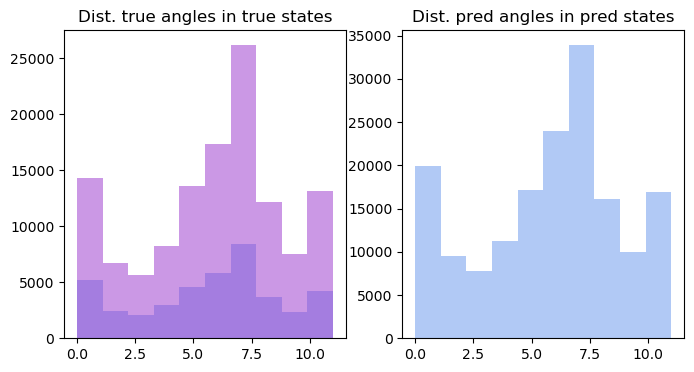

In [9]:
"""Distribution of angles in the two states"""
pred_latents_1, pred_angles_1 = glm_hmm_1.sample(len(obs), input=noisyinpt)

fig, axs = plt.subplots(1,2,figsize = (8,4))
axs[0].hist(obs[state == 0], alpha = .5, color = ['cornflowerblue'])
axs[0].hist(obs[state == 1], alpha = .5, color = ['darkorchid'])
axs[0].set_title('Dist. true angles in true states')

axs[1].hist(pred_angles_1[pred_latents_1 == 0], alpha = .5, color = ['cornflowerblue'])
axs[1].set_title('Dist. pred angles in pred states')

Text(0.5, 1.0, 'all_time')

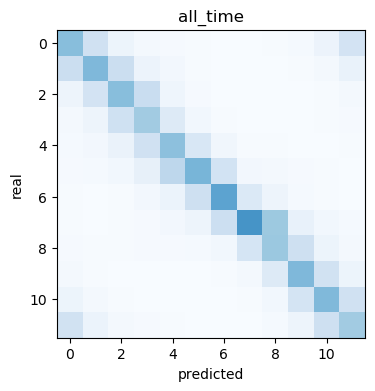

In [10]:
"""Based on the inputs, what does it think the angles should be?"""
conf = confusion_matrix(obs, pred_angles_1)
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)

fig, axs = plt.subplots(1,1,figsize = (12,4))
axs.imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs.set_ylabel("real")
axs.set_xlabel("predicted")
axs.set_title("all_time")

Text(0.5, 1.0, 'weights per category in the two states')

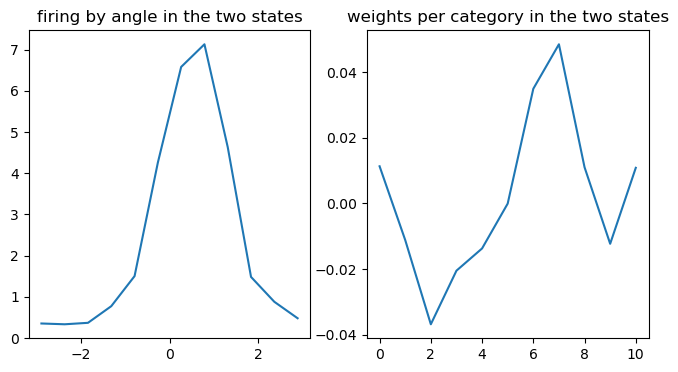

In [22]:
"""How do the tuning curves compare to the weights?"""
idx = 21
fig,ax = plt.subplots(1,2,figsize = (8,4))
ax[0].plot(bin_angle_center,firing_by_angle_bin(obs[state == 0],noisyinpt[state == 0,idx], number_of_bins))
ax[0].set_title("firing by angle")
ax[0].set_xlabel('angles (rad)')

ax[1].plot(glm_hmm_1.observations.Wk[0,:,idx])
ax[1].set_title("weights per category")

In [81]:
"""Try to fit a GLM-HMM"""
num_states = 2 # by design
obs_dim = 1 # hdir
input_dim = np.shape(inpt)[1] # n_neurons
num_categories = len(np.unique(obs)) # n_bins of hdir
N_iters = 100
prior_sigma = 2 # needs a grid search!

# initiate the HMM
glm_hmm_2 = ssm.HMM(num_states, 
                  obs_dim, 
                  input_dim, 
                  observations="input_driven_obs", # maybe this allows to pass a categorical observation?!
                  observation_kwargs=dict(C=num_categories, prior_sigma = prior_sigma),
                  transitions="sticky",
                  transition_kwargs=dict(alpha=1,kappa=0)) 

# fit the HMM
ll2 = glm_hmm_2.fit([np.array([[o] for o in obs])], inputs=[noisyinpt], method="em", num_iters=N_iters, tolerance=10**-4)

  0%|          | 0/100 [00:00<?, ?it/s]

Go over the inputs

In [60]:
# not sure how to parse this - what does it all mean?
w = glm_hmm_2.expected_states(np.array([[o] for o in obs]), input=noisyinpt)

In [186]:
"""Find permutation"""
# what is this doing? this only works if you know the actual states... very sus
from ssm.util import find_permutation
glm_hmm_2.permute(find_permutation(state, glm_hmm_2.most_likely_states(np.array([[o] for o in obs]), input=noisyinpt)))

In [53]:
"""How well did it guess the transition matrix?"""
if case == "matrix":
    print('predicted transitions matrix are: ' + str([list(glm_hmm_2.transitions.transition_matrix[0]),list(glm_hmm_2.transitions.transition_matrix[1])]) + '\n input transition matrix are: ' + str(trans_matrix))
else:
    print('predicted transitions matrix are: ' + str([list(glm_hmm_2.transitions.transition_matrix[0]),list(glm_hmm_2.transitions.transition_matrix[1])]))

predicted transitions matrix are: [[0.9450273899416407, 0.05497261005835937], [0.06417918130082506, 0.935820818699175]]
 input transition matrix are: [[0.94, 0.06], [0.02, 0.98]]


Text(0.5, 1.0, '% time in state 0, real: 0.16 , predicted: 0.51\n% time in state 1, real: 0.84 , predicted: 0.49')

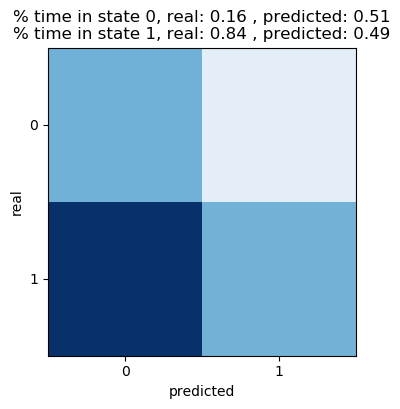

In [82]:
"""How well did it guess the states?"""
state_pred = glm_hmm_2.most_likely_states(np.array([[o] for o in obs]), input=noisyinpt)
# alternative method
# posterior_probs = glm_hmm_2.expected_states(np.array([[o] for o in obs]), input=noisyinpt)[0]
# exp_state = np.argmax(posterior_probs, axis = 1)

conf = confusion_matrix(state, state_pred)
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)

fig, axs = plt.subplots(1,1,figsize = (4,4))
axs.imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs.set_ylabel("real")
axs.set_xlabel("predicted")
axs.set_xticks([0,1])
axs.set_yticks([0,1])
axs.set_title('% time in state 0, real: ' + "%.2f" % (np.sum(state == 0)/len(state)) +' , predicted: ' + "%.2f" % (np.sum(state_pred == 0)/len(state_pred)) +
              '\n% time in state 1, real: ' + "%.2f" % (np.sum(state == 1)/len(state)) +' , predicted: ' + "%.2f" % (np.sum(state_pred == 1)/len(state_pred)))

Text(0, 0.5, 'Fraction of state bouts')

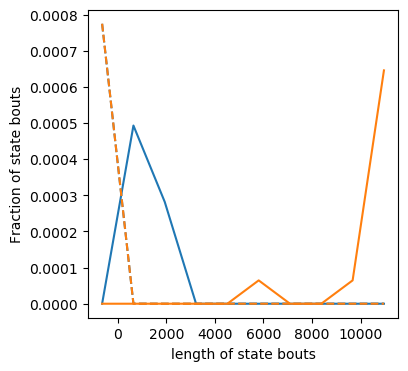

In [83]:
"""How long does each state bout last?"""

real_time = []
for i in np.arange(num_states):
    st = (state == i).astype(int)
    if st[0] == 1:
        st = np.hstack((np.zeros(1),st))
    if st[-1] == 1:
        st = np.hstack((st,np.zeros(1)))
    start = np.where(np.diff(st) == 1)[0]
    end = np.where(np.diff(st) == -1)[0]
    real_time.append(np.abs(start - end))


pred_time = []
for i in np.arange(num_states):
    st = (state_pred == i).astype(int)
    if st[0] == 1:
        st = np.hstack((np.zeros(1),st))
    if st[-1] == 1:
        st = np.hstack((st,np.zeros(1)))
    start = np.where(np.diff(st) == 1)[0]
    end = np.where(np.diff(st) == -1)[0]
    pred_time.append(np.abs(start - end))

longest = np.amax(np.append(np.concatenate(pred_time), np.concatenate(real_time)))
shortest = np.amin(np.append(np.concatenate(pred_time), np.concatenate(real_time)))

fig, axs = plt.subplots(1,1,figsize = (4,4))
colorz = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i in np.arange(num_states):
    # real
    h, b = np.histogram(real_time[i],range = (shortest,longest), density = True)
    bc = b[:-1]-np.mean(np.diff(b))/2
    axs.plot(bc,h, '-', color = colorz[i])
    # pred
    h, b = np.histogram(pred_time[i],range = (shortest,longest), density = True)
    bc = b[:-1]-np.mean(np.diff(b))/2
    axs.plot(bc,h, '--', color = colorz[i])

axs.set_xlabel('length of state bouts')
axs.set_ylabel('Fraction of state bouts')

Text(0.5, 1.0, 'Dist. pred angles in pred states')

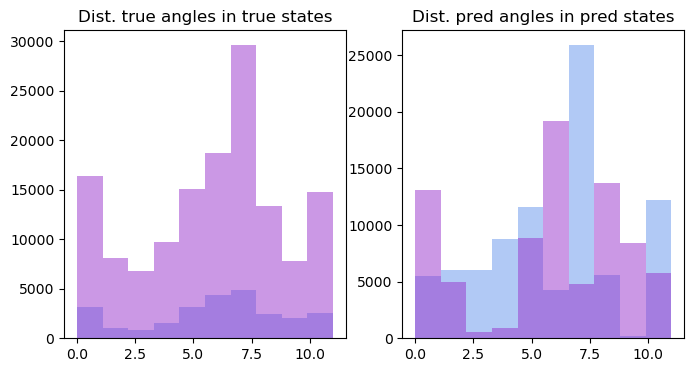

In [84]:
"""Distribution of angles in the two states"""
pred_latents, pred_angles = glm_hmm_2.sample(len(obs), input=noisyinpt)

fig, axs = plt.subplots(1,2,figsize = (8,4))
axs[0].hist(obs[state == 0], alpha = .5, color = ['cornflowerblue'])
axs[0].hist(obs[state == 1], alpha = .5, color = ['darkorchid'])
axs[0].set_title('Dist. true angles in true states')

axs[1].hist(pred_angles[pred_latents == 0], alpha = .5, color = ['cornflowerblue'])
axs[1].hist(pred_angles[pred_latents == 1], alpha = .5, color = ['darkorchid'])
axs[1].set_title('Dist. pred angles in pred states')

Text(0.5, 1.0, 'pred state 1')

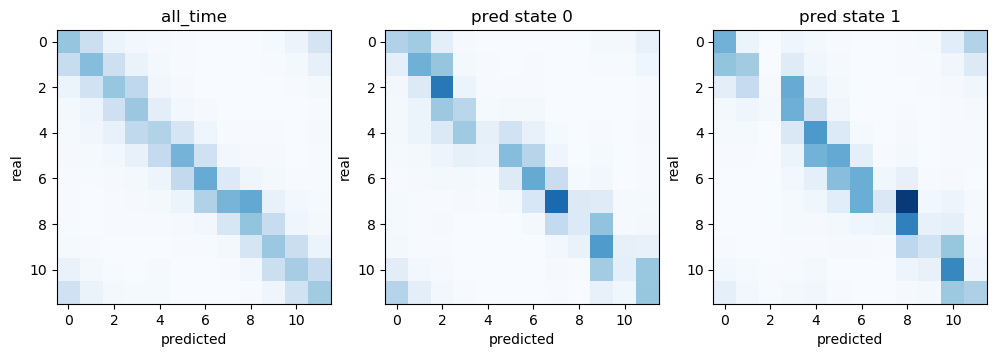

In [77]:
"""Based on the inputs, what does it think the angles should be?"""
conf = confusion_matrix(obs, pred_angles)
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)

fig, axs = plt.subplots(1,3,figsize = (12,4))
axs[0].imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs[0].set_ylabel("real")
axs[0].set_xlabel("predicted")
axs[0].set_title("all_time")

conf = confusion_matrix(obs[pred_latents == 0], pred_angles[pred_latents == 0])
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)
axs[1].imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs[1].set_ylabel("real")
axs[1].set_xlabel("predicted")
axs[1].set_title("pred state 0")

conf = confusion_matrix(obs[pred_latents == 1], pred_angles[pred_latents == 1])
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)
axs[2].imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs[2].set_ylabel("real")
axs[2].set_xlabel("predicted")
axs[2].set_title("pred state 1")

Text(0.5, 1.0, 'weights per category in the two states')

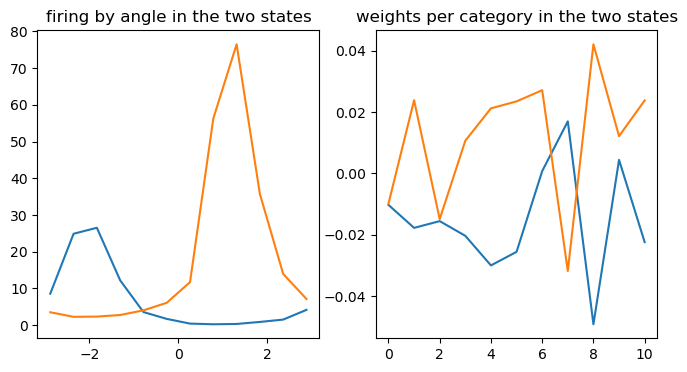

In [80]:
def firing_by_angle_bin(angles, neural_activity, nbins):
    angles_firing = np.zeros(nbins - 1)
    unique_groups, group_counts = np.unique(angles, return_counts=True)
    group_sums = np.bincount(angles, weights=neural_activity)
    angles_firing[unique_groups] = group_sums[unique_groups] / group_counts
    return angles_firing

idx = 6
fig,ax = plt.subplots(1,2,figsize = (8,4))
ax[0].plot(bin_angle_center,firing_by_angle_bin(obs[state == 0],noisyinpt[state == 0,idx], number_of_bins))
ax[0].plot(bin_angle_center,firing_by_angle_bin(obs[state == 1],noisyinpt[state == 1,idx], number_of_bins))
ax[0].set_title("firing by angle in the two states")

ax[1].plot(glm_hmm_2.observations.Wk[0,:,idx])
ax[1].plot(glm_hmm_2.observations.Wk[1,:,idx])
ax[1].set_title("weights per category in the two states")

Compare model performance

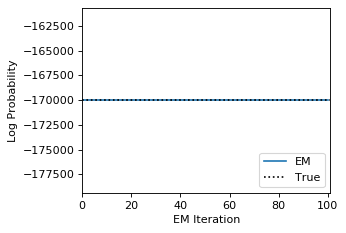

In [32]:
# Plot the log probabilities of the true and fit models. Fit model final LL should be greater 
# than or equal to true LL.

true_ll_1 = glm_hmm_1.log_probability(np.array([[o] for o in obs]), inputs=noisyinpt) 

fig = plt.figure(figsize=(4, 3), dpi=80, facecolor='w', edgecolor='k')
plt.plot(ll1, label="EM")
plt.plot([0, len(ll1)], true_ll_1 * np.ones(2), ':k', label="True")
plt.legend(loc="lower right")
plt.xlabel("EM Iteration")
plt.xlim(0, len(ll1))
plt.ylabel("Log Probability")
plt.show()

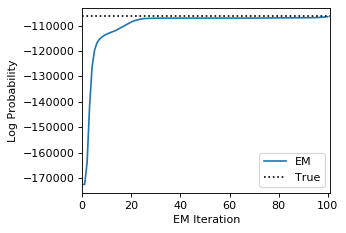

In [31]:
# Plot the log probabilities of the true and fit models. Fit model final LL should be greater 
# than or equal to true LL.

true_ll_2 = glm_hmm_2.log_probability(np.array([[o] for o in obs]), inputs=noisyinpt) 

fig = plt.figure(figsize=(4, 3), dpi=80, facecolor='w', edgecolor='k')
plt.plot(ll2, label="EM")
plt.plot([0, len(ll2)], true_ll_2 * np.ones(2), ':k', label="True")
plt.legend(loc="lower right")
plt.xlabel("EM Iteration")
plt.xlim(0, len(ll2))
plt.ylabel("Log Probability")
plt.show()